In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Epoch 200/2000, loss = 0.014911
Epoch 400/2000, loss = 0.002181
Epoch 600/2000, loss = 0.000496
Epoch 800/2000, loss = 0.000223
Epoch 1000/2000, loss = 0.000215
Epoch 1200/2000, loss = 0.000100
Epoch 1400/2000, loss = 0.000121
Epoch 1600/2000, loss = 0.000105
Epoch 1800/2000, loss = 0.000039
Epoch 2000/2000, loss = 0.000046


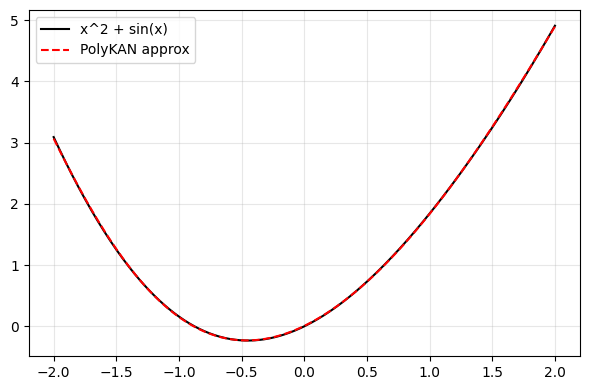

In [2]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------- Recursive polynomial basis ----------

class RecursivePolyBasis(nn.Module):
    """
    R_0(x) = 0
    R_1(x) = 1
    R_{n+1}(x) = (a x^2 + b x + c) R_n(x) + (d x + e) R_{n-1}(x)
    y = sum_{n=0}^K w_n R_n(x)
    """
    def __init__(self, K, init_like_cheb=True, param_bound=3.0):
        super().__init__()
        self.K = K
        self.param_bound = param_bound

        # unconstrained parameters (we will squash with tanh)
        self.a_raw = nn.Parameter(torch.zeros(1))
        self.b_raw = nn.Parameter(torch.zeros(1))
        self.c_raw = nn.Parameter(torch.zeros(1))
        self.d_raw = nn.Parameter(torch.zeros(1))
        self.e_raw = nn.Parameter(torch.zeros(1))

        # weights for basis
        self.w = nn.Parameter(torch.zeros(K + 1))

        if init_like_cheb:
            with torch.no_grad():
                # approximate Chebyshev-like: 2x * R_n - R_{n-1}
                self.a_raw.fill_(0.0)
                # tanh^-1(2/param_bound) but keep small to avoid saturation
                self.b_raw.fill_(0.5)
                self.c_raw.fill_(0.0)
                self.d_raw.fill_(0.0)
                self.e_raw.fill_(-0.5)
                self.w.normal_(mean=0.0, std=0.01)

    def _squash_params(self):
        # map raw params to bounded range via tanh for stability
        a = self.param_bound * torch.tanh(self.a_raw)
        b = self.param_bound * torch.tanh(self.b_raw)
        c = self.param_bound * torch.tanh(self.c_raw)
        d = self.param_bound * torch.tanh(self.d_raw)
        e = self.param_bound * torch.tanh(self.e_raw)
        return a, b, c, d, e

    def forward(self, x):
        """
        x: tensor of shape (batch,) or (batch,1)
        returns: (batch,)
        """
        if x.dim() > 1:
            x = x.squeeze(-1)

        # assume x already in a reasonable range; optional clip
        x = x.clamp(-2.0, 2.0)

        a, b, c, d, e = self._squash_params()

        R0 = torch.zeros_like(x)
        R1 = torch.ones_like(x)

        Rs = [R0, R1]

        for n in range(1, self.K):
            coef1 = a * x**2 + b * x + c
            coef2 = d * x + e
            R_next = coef1 * Rs[-1] + coef2 * Rs[-2]
            Rs.append(R_next)

        R_stack = torch.stack(Rs, dim=-1)  # (batch, K+1)
        y = (R_stack * self.w).sum(dim=-1)
        return y

# ---------- Simple model: linear in -> recursive basis out ----------

class PolyKAN1D(nn.Module):
    def __init__(self, K):
        super().__init__()
        # one linear projection (can be identity, but we keep flexibility)
        self.lin = nn.Linear(1, 1)
        self.basis = RecursivePolyBasis(K=K, init_like_cheb=True)

    def forward(self, x):
        # x: (batch,1)
        h = self.lin(x)           # (batch,1)
        h = h.squeeze(-1)         # (batch,)
        y = self.basis(h)         # (batch,)
        return y.unsqueeze(-1)    # (batch,1)

# ---------- Target function f(x) = x^2 + sin(x) ----------

def target_function(x):
    return x**2 + torch.sin(x)

# ---------- Training loop ----------

def train_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # hyperparameters
    K = 8            # number of basis functions - 1 (we get R_0..R_K)
    n_samples = 2000
    n_epochs = 2000
    batch_size = 256
    lr = 1e-3

    # data: uniform on [-2, 2]
    x_all = (4.0 * torch.rand(n_samples, 1) - 2.0).to(device)
    y_all = target_function(x_all).to(device)

    model = PolyKAN1D(K=K).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(1, n_epochs + 1):
        perm = torch.randperm(n_samples)
        x_all = x_all[perm]
        y_all = y_all[perm]

        for i in range(0, n_samples, batch_size):
            x_batch = x_all[i:i+batch_size]
            y_batch = y_all[i:i+batch_size]

            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch % 200 == 0:
            print(f"Epoch {epoch}/{n_epochs}, loss = {loss.item():.6f}")

    # evaluate on a fine grid for plotting
    x_test = torch.linspace(-2, 2, 400).unsqueeze(-1).to(device)
    with torch.no_grad():
        y_pred = model(x_test)
    y_true = target_function(x_test)

    x_np = x_test.cpu().numpy().squeeze()
    y_pred_np = y_pred.cpu().numpy().squeeze()
    y_true_np = y_true.cpu().numpy().squeeze()

    plt.figure(figsize=(6,4))
    plt.plot(x_np, y_true_np, label='x^2 + sin(x)', color='black')
    plt.plot(x_np, y_pred_np, label='PolyKAN approx', color='red', linestyle='--')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_model()


Epoch 200/2000, loss = 0.005976
Epoch 400/2000, loss = 0.000630
Epoch 600/2000, loss = 0.000011
Epoch 800/2000, loss = 0.000013
Epoch 1000/2000, loss = 0.000000
Epoch 1200/2000, loss = 0.000002
Epoch 1400/2000, loss = 0.000001
Epoch 1600/2000, loss = 0.000001
Epoch 1800/2000, loss = 0.000003
Epoch 2000/2000, loss = 0.000001

Learned recurrence parameters (after tanh squash):
a = 0.1525, b = 1.4698, c = -0.4020, d = -0.0205, e = -0.9552
w = [-2.0491320e-03  3.4273139e-01 -2.4479392e-01  5.7775354e-01
 -2.2929216e-02 -3.9217886e-04 -1.0611034e-03  6.1550725e-04
 -1.5788848e-04]


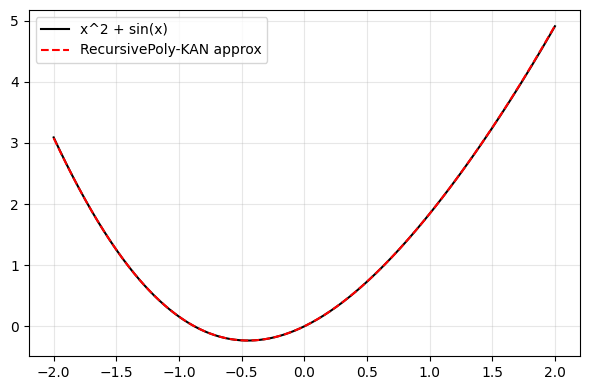

In [4]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ================= Recursive polynomial basis =================

class RecursivePolyBasis(nn.Module):
    """
    Learnable recursive polynomial basis for KAN edges:

        R_0(x) = 0
        R_1(x) = 1      (can be seen as a constant basis term)
        R_{n+1}(x) = (a x^2 + b x + c) R_n(x) + (d x + e) R_{n-1}(x)

    Edge output:
        y(x) = sum_{n=0}^K w_n R_n(x)

    a,b,c,d,e are shared across n and are learned from data.
    """
    def __init__(self, K, init_like_cheb=True, param_bound=3.0):
        super().__init__()
        self.K = K
        self.param_bound = param_bound

        # unconstrained parameters (squashed via tanh to keep them bounded)
        self.a_raw = nn.Parameter(torch.zeros(1))
        self.b_raw = nn.Parameter(torch.zeros(1))
        self.c_raw = nn.Parameter(torch.zeros(1))
        self.d_raw = nn.Parameter(torch.zeros(1))
        self.e_raw = nn.Parameter(torch.zeros(1))

        # weights for linear combination of basis functions
        self.w = nn.Parameter(torch.zeros(K + 1))

        if init_like_cheb:
            with torch.no_grad():
                # heuristics: make it vaguely look like Chebyshev: R_{n+1} ≈ 2x R_n - R_{n-1}
                self.a_raw.fill_(0.0)
                self.b_raw.fill_(0.5)   # tanh(0.5) ≈ 0.46 -> ~ 1.4 * x
                self.c_raw.fill_(0.0)
                self.d_raw.fill_(0.0)
                self.e_raw.fill_(-0.5)
                self.w.normal_(mean=0.0, std=0.01)

    def _squash_params(self):
        # map raw params to [-param_bound, param_bound]
        a = self.param_bound * torch.tanh(self.a_raw)
        b = self.param_bound * torch.tanh(self.b_raw)
        c = self.param_bound * torch.tanh(self.c_raw)
        d = self.param_bound * torch.tanh(self.d_raw)
        e = self.param_bound * torch.tanh(self.e_raw)
        return a, b, c, d, e

    def forward(self, x):
        """
        x: tensor of shape (batch,) or (batch,1)
        returns: (batch,)
        """
        if x.dim() > 1:
            x = x.squeeze(-1)

        # optional clipping for numerical stability
        x = x.clamp(-2.0, 2.0)

        a, b, c, d, e = self._squash_params()

        # initial polynomials
        R0 = torch.zeros_like(x)   # R_0(x)
        R1 = torch.ones_like(x)    # R_1(x)

        Rs = [R0, R1]

        # build R_2,...,R_K by recurrence
        for n in range(1, self.K):
            coef1 = a * x**2 + b * x + c
            coef2 = d * x + e
            R_next = coef1 * Rs[-1] + coef2 * Rs[-2]
            Rs.append(R_next)

        # shape: (batch, K+1)
        R_stack = torch.stack(Rs, dim=-1)

        # linear combination along basis index
        y = (R_stack * self.w).sum(dim=-1)
        return y

# ================= Simple 1D Poly-KAN model =================

class PolyKAN1D(nn.Module):
    """
    Minimal KAN-like 1D model: linear projection + recursive polynomial basis.
    """
    def __init__(self, K):
        super().__init__()
        self.lin = nn.Linear(1, 1)
        self.basis = RecursivePolyBasis(K=K, init_like_cheb=True)

    def forward(self, x):
        # x: (batch,1)
        h = self.lin(x)           # (batch,1)
        h = h.squeeze(-1)         # (batch,)
        y = self.basis(h)         # (batch,)
        return y.unsqueeze(-1)    # (batch,1)

# ================= Target function and data =================

def target_function(x):
    # x: (batch,1)
    return x**2 + torch.sin(x)

def make_dataset(n_samples, device):
    # sample uniformly on [-2, 2]
    x = 4.0 * torch.rand(n_samples, 1, device=device) - 2.0
    y = target_function(x)
    return x, y

# ================= Training and evaluation =================

def train_and_eval():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # hyperparameters
    K = 8
    n_samples = 2000
    n_epochs = 2000
    batch_size = 256
    lr = 1e-3

    # data
    x_all, y_all = make_dataset(n_samples, device)

    model = PolyKAN1D(K=K).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(1, n_epochs + 1):
        perm = torch.randperm(n_samples, device=device)
        x_all = x_all[perm]
        y_all = y_all[perm]

        for i in range(0, n_samples, batch_size):
            x_batch = x_all[i:i+batch_size]
            y_batch = y_all[i:i+batch_size]

            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch % 200 == 0:
            print(f"Epoch {epoch}/{n_epochs}, loss = {loss.item():.6f}")

    # print learned parameters
    basis = model.basis
    a, b, c, d, e = basis._squash_params()
    print("\nLearned recurrence parameters (after tanh squash):")
    print(f"a = {a.item():.4f}, b = {b.item():.4f}, c = {c.item():.4f}, d = {d.item():.4f}, e = {e.item():.4f}")
    print("w =", basis.w.data.cpu().numpy())

    # evaluate on a dense grid for plotting
    x_test = torch.linspace(-2, 2, 400, device=device).unsqueeze(-1)
    with torch.no_grad():
        y_pred = model(x_test)
    y_true = target_function(x_test)

    # to numpy
    x_np = x_test.cpu().numpy().squeeze()
    y_pred_np = y_pred.cpu().numpy().squeeze()
    y_true_np = y_true.cpu().numpy().squeeze()

    # plot
    plt.figure(figsize=(6, 4))
    plt.plot(x_np, y_true_np, label='x^2 + sin(x)', color='black')
    plt.plot(x_np, y_pred_np, label='RecursivePoly-KAN approx', color='red', linestyle='--')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_and_eval()


In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# =========================
# 1. Recursive polynomial basis (ایده خودت)
# =========================

def recursive_poly_basis(x, degree, a_raw, b_raw, c_raw, d_raw, e_raw, param_bound=3.0):
    """
    Build R_0..R_degree for input x via:

        R_0(x) = 0
        R_1(x) = 1
        R_{n+1}(x)
          = (a x^2 + b x + c) R_n(x) + (d x + e) R_{n-1}(x)

    a,b,c,d,e از tanh روی پارامترهای خام می‌آیند.
    x: [batch, input_dim]
    Returns: [batch, input_dim, degree+1]
    """
    # squash params to bounded range
    a = param_bound * torch.tanh(a_raw)
    b = param_bound * torch.tanh(b_raw)
    c = param_bound * torch.tanh(c_raw)
    d = param_bound * torch.tanh(d_raw)
    e = param_bound * torch.tanh(e_raw)

    # برای پایداری
    x = x.clamp(-2.0, 2.0)

    Rm1 = torch.zeros_like(x)   # R_0
    R0  = torch.ones_like(x)    # R_1

    polys = [Rm1, R0]  # index 0 -> R_0, index 1 -> R_1

    for n in range(1, degree):
        coef1 = a * x**2 + b * x + c
        coef2 = d * x + e
        R1 = coef1 * R0 + coef2 * Rm1
        polys.append(R1)
        Rm1, R0 = R0, R1

    # polys: R_0..R_degree
    return torch.stack(polys, dim=-1)


class RecursivePolyKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, param_bound=3.0):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        self.param_bound = param_bound

        # weights: [output_dim, input_dim, degree+1]
        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        # shared recurrence params for این لایه
        self.a_raw = nn.Parameter(torch.tensor(0.0))
        self.b_raw = nn.Parameter(torch.tensor(0.0))
        self.c_raw = nn.Parameter(torch.tensor(0.0))
        self.d_raw = nn.Parameter(torch.tensor(0.0))
        self.e_raw = nn.Parameter(torch.tensor(0.0))

        # init شبیه Chebyshev: R_{n+1} ≈ 2x R_n - R_{n-1}
        with torch.no_grad():
            self.a_raw.fill_(0.0)
            self.b_raw.fill_(0.5)
            self.c_raw.fill_(0.0)
            self.d_raw.fill_(0.0)
            self.e_raw.fill_(-0.5)

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        polys = recursive_poly_basis(
            x, self.degree,
            self.a_raw, self.b_raw, self.c_raw, self.d_raw, self.e_raw,
            param_bound=self.param_bound
        )
        # b i d, o i d -> b o
        out = torch.einsum('bid, oid -> bo', polys, self.weights)
        return out


class RecursivePolyKAN_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.kan1 = RecursivePolyKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = RecursivePolyKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = RecursivePolyKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# =========================
# 2. Data loaders
# =========================

MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)


def make_mnist_loaders(batch_size=64):
    train_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])

    train_ds = datasets.MNIST('./data_mnist',
                              train=True,
                              download=True,
                              transform=train_tf)
    test_ds = datasets.MNIST('./data_mnist',
                             train=False,
                             download=True,
                             transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=1000,
                             shuffle=False, num_workers=0)
    return train_loader, test_loader


# =========================
# 3. Training loop
# =========================

def train_mnist(epochs=50, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Recursive-Polynomial KAN on MNIST")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    train_loader, test_loader = make_mnist_loaders(batch_size=batch_size)

    model = RecursivePolyKAN_MNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_test_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # eval روی test
        model.eval()
        correct_te, total_te = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct_te += pred.eq(target).sum().item()
                total_te += target.size(0)
        test_acc = 100.0 * correct_te / total_te
        best_test_acc = max(best_test_acc, test_acc)

        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start

        # log recurrence params (یک لایه اول برای دیدن رفتار)
        with torch.no_grad():
            a = torch.tanh(model.kan1.a_raw).item()
            b = torch.tanh(model.kan1.b_raw).item()
            c = torch.tanh(model.kan1.c_raw).item()
            d = torch.tanh(model.kan1.d_raw).item()
            e = torch.tanh(model.kan1.e_raw).item()

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}% | Best Test: {best_test_acc:.2f}% "
              f"| Time: {elapsed:.1f}s")
        print(f"  Recurrence (tanh-scaled, layer1): "
              f"a={a:.3f}, b={b:.3f}, c={c:.3f}, d={d:.3f}, e={e:.3f}")

        scheduler.step()

    return model


# =========================
# 4. Main
# =========================

if __name__ == '__main__':
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 50
    BATCH_SIZE = 64

    model = train_mnist(epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        device=DEVICE)

    torch.save(model.state_dict(), 'recursive_poly_kan_mnist.pth')
    print("Model saved: recursive_poly_kan_mnist.pth")


Recursive-Polynomial KAN on MNIST
Device: cuda | Epochs: 50 | Batch: 64


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.17MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.73MB/s]


Epoch  1/50 | Loss: 0.2792 | Test Acc: 96.43% | Best Test: 96.43% | Time: 20.5s
  Recurrence (tanh-scaled, layer1): a=0.166, b=0.615, c=0.195, d=0.191, e=-0.363
Epoch  2/50 | Loss: 0.1314 | Test Acc: 96.79% | Best Test: 96.79% | Time: 20.3s
  Recurrence (tanh-scaled, layer1): a=0.207, b=0.684, c=0.245, d=0.271, e=-0.340
Epoch  3/50 | Loss: 0.1037 | Test Acc: 97.31% | Best Test: 97.31% | Time: 20.4s
  Recurrence (tanh-scaled, layer1): a=0.241, b=0.744, c=0.274, d=0.325, e=-0.319
Epoch  4/50 | Loss: 0.0876 | Test Acc: 97.13% | Best Test: 97.31% | Time: 19.7s
  Recurrence (tanh-scaled, layer1): a=0.264, b=0.785, c=0.287, d=0.372, e=-0.313
Epoch  5/50 | Loss: 0.0736 | Test Acc: 97.80% | Best Test: 97.80% | Time: 20.3s
  Recurrence (tanh-scaled, layer1): a=0.283, b=0.820, c=0.305, d=0.402, e=-0.297
Epoch  6/50 | Loss: 0.0642 | Test Acc: 97.95% | Best Test: 97.95% | Time: 20.9s
  Recurrence (tanh-scaled, layer1): a=0.307, b=0.849, c=0.311, d=0.429, e=-0.287
Epoch  7/50 | Loss: 0.0601 | Test 

In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# =========================
# 1. Recursive polynomial basis
# =========================

def recursive_poly_basis(x, degree, a_raw, b_raw, c_raw, d_raw, e_raw, param_bound=3.0):
    a = param_bound * torch.tanh(a_raw)
    b = param_bound * torch.tanh(b_raw)
    c = param_bound * torch.tanh(c_raw)
    d = param_bound * torch.tanh(d_raw)
    e = param_bound * torch.tanh(e_raw)

    x = x.clamp(-2.0, 2.0)

    Rm1 = torch.zeros_like(x)   # R_0
    R0 = torch.ones_like(x)     # R_1

    polys = [Rm1, R0]

    for _ in range(1, degree):
        coef1 = a * x**2 + b * x + c
        coef2 = d * x + e
        R1 = coef1 * R0 + coef2 * Rm1
        polys.append(R1)
        Rm1, R0 = R0, R1

    return torch.stack(polys, dim=-1)


class RecursivePolyKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree=3, param_bound=3.0):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        self.param_bound = param_bound

        self.weights = nn.Parameter(
            torch.randn(output_dim, input_dim, degree + 1) * 0.02
        )

        self.a_raw = nn.Parameter(torch.tensor(0.0))
        self.b_raw = nn.Parameter(torch.tensor(0.0))
        self.c_raw = nn.Parameter(torch.tensor(0.0))
        self.d_raw = nn.Parameter(torch.tensor(0.0))
        self.e_raw = nn.Parameter(torch.tensor(0.0))

        with torch.no_grad():
            self.a_raw.fill_(0.0)
            self.b_raw.fill_(0.5)
            self.c_raw.fill_(0.0)
            self.d_raw.fill_(0.0)
            self.e_raw.fill_(-0.5)

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.shape[0], -1)

        polys = recursive_poly_basis(
            x, self.degree,
            self.a_raw, self.b_raw, self.c_raw, self.d_raw, self.e_raw,
            param_bound=self.param_bound
        )
        out = torch.einsum('bid,oid->bo', polys, self.weights)
        return out


class RecursivePolyKAN_FashionMNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=64, num_classes=10, degree=3):
        super().__init__()
        self.flatten = nn.Flatten()

        self.kan1 = RecursivePolyKANLayer(input_dim, hidden_dim, degree=degree)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.drop1 = nn.Dropout(0.1)

        self.kan2 = RecursivePolyKANLayer(hidden_dim, hidden_dim, degree=degree)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop2 = nn.Dropout(0.1)

        self.kan3 = RecursivePolyKANLayer(hidden_dim, num_classes, degree=degree)

    def forward(self, x):
        x = self.flatten(x)
        x = self.kan1(x)
        x = self.norm1(x)
        x = self.drop1(x)

        x = self.kan2(x)
        x = self.norm2(x)
        x = self.drop2(x)

        x = self.kan3(x)
        return x


# =========================
# 2. Data loaders
# =========================

FASHION_MNIST_MEAN = (0.2860,)
FASHION_MNIST_STD = (0.3530,)

def make_fashion_mnist_loaders(batch_size=64, val_size=5000):
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(FASHION_MNIST_MEAN, FASHION_MNIST_STD)
    ])

    full_train_ds = datasets.FashionMNIST(
        './data_fashion_mnist',
        train=True,
        download=True,
        transform=tf
    )

    test_ds = datasets.FashionMNIST(
        './data_fashion_mnist',
        train=False,
        download=True,
        transform=tf
    )

    train_size = len(full_train_ds) - val_size
    train_ds, val_ds = random_split(
        full_train_ds,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=1000, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=1000, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader


# =========================
# 3. Training loop
# =========================

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            out = model(data)
            loss = criterion(out, target)
            pred = out.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
            loss_sum += loss.item()

    return loss_sum / len(loader), 100.0 * correct / total


def train_fashion_mnist(epochs=50, batch_size=64, device='cuda'):
    print("=" * 60)
    print("Recursive-Polynomial KAN on Fashion-MNIST")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    train_loader, val_loader, test_loader = make_fashion_mnist_loaders(batch_size=batch_size)

    model = RecursivePolyKAN_FashionMNIST(
        input_dim=784, hidden_dim=64, num_classes=10, degree=3
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_test_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        val_loss, val_acc = evaluate(model, val_loader, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        best_val_acc = max(best_val_acc, val_acc)
        best_test_acc = max(best_test_acc, test_acc)

        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start

        with torch.no_grad():
            a = torch.tanh(model.kan1.a_raw).item()
            b = torch.tanh(model.kan1.b_raw).item()
            c = torch.tanh(model.kan1.c_raw).item()
            d = torch.tanh(model.kan1.d_raw).item()
            e = torch.tanh(model.kan1.e_raw).item()

        print(
            f"Epoch {epoch:2d}/{epochs} | "
            f"Train Loss: {avg_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}% | Best Val: {best_val_acc:.2f}% | "
            f"Test Acc: {test_acc:.2f}% | Best Test: {best_test_acc:.2f}% | "
            f"Time: {elapsed:.1f}s"
        )
        print(
            f"  Recurrence (tanh-scaled, layer1): "
            f"a={a:.3f}, b={b:.3f}, c={c:.3f}, d={d:.3f}, e={e:.3f}"
        )

        scheduler.step()

    return model


# =========================
# 4. Main
# =========================

if __name__ == '__main__':
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 50
    BATCH_SIZE = 64

    model = train_fashion_mnist(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        device=DEVICE
    )

    torch.save(model.state_dict(), 'recursive_poly_kan_fashion_mnist.pth')
    print("Model saved: recursive_poly_kan_fashion_mnist.pth")

Recursive-Polynomial KAN on Fashion-MNIST
Device: cuda | Epochs: 50 | Batch: 64


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]


Epoch  1/50 | Train Loss: 0.5453 | Val Acc: 84.94% | Best Val: 84.94% | Test Acc: 84.20% | Best Test: 84.20% | Time: 20.5s
  Recurrence (tanh-scaled, layer1): a=-0.138, b=0.552, c=0.108, d=0.070, e=-0.483
Epoch  2/50 | Train Loss: 0.3933 | Val Acc: 86.30% | Best Val: 86.30% | Test Acc: 85.83% | Best Test: 85.83% | Time: 19.3s
  Recurrence (tanh-scaled, layer1): a=-0.151, b=0.586, c=0.115, d=0.058, e=-0.574
Epoch  3/50 | Train Loss: 0.3532 | Val Acc: 87.02% | Best Val: 87.02% | Test Acc: 86.65% | Best Test: 86.65% | Time: 19.4s
  Recurrence (tanh-scaled, layer1): a=-0.158, b=0.617, c=0.110, d=0.046, e=-0.639
Epoch  4/50 | Train Loss: 0.3214 | Val Acc: 87.54% | Best Val: 87.54% | Test Acc: 87.38% | Best Test: 87.38% | Time: 19.7s
  Recurrence (tanh-scaled, layer1): a=-0.166, b=0.634, c=0.115, d=0.043, e=-0.697
Epoch  5/50 | Train Loss: 0.3012 | Val Acc: 87.88% | Best Val: 87.88% | Test Acc: 87.26% | Best Test: 87.38% | Time: 19.4s
  Recurrence (tanh-scaled, layer1): a=-0.158, b=0.652, c=

KeyboardInterrupt: 

Epoch 0/50000  RecKAN loss: 1358.7985  MLP loss: 0.6295
Epoch 1000/50000  RecKAN loss: 0.2233  MLP loss: 0.2239
Epoch 2000/50000  RecKAN loss: 0.2137  MLP loss: 0.2227
Epoch 3000/50000  RecKAN loss: 0.2182  MLP loss: 0.2221
Epoch 4000/50000  RecKAN loss: 0.2126  MLP loss: 0.2215
Epoch 5000/50000  RecKAN loss: 0.2075  MLP loss: 0.2210
Epoch 6000/50000  RecKAN loss: 0.2067  MLP loss: 0.2206
Epoch 7000/50000  RecKAN loss: 0.2237  MLP loss: 0.2203
Epoch 8000/50000  RecKAN loss: 0.2230  MLP loss: 0.2251
Epoch 9000/50000  RecKAN loss: 0.2225  MLP loss: 0.2198
Epoch 10000/50000  RecKAN loss: 0.2216  MLP loss: 0.2193
Epoch 11000/50000  RecKAN loss: 0.2208  MLP loss: 0.2019
Epoch 12000/50000  RecKAN loss: 0.2194  MLP loss: 0.1963
Epoch 13000/50000  RecKAN loss: 0.2089  MLP loss: 0.1942
Epoch 14000/50000  RecKAN loss: 0.1724  MLP loss: 0.1925
Epoch 15000/50000  RecKAN loss: 0.1370  MLP loss: 0.1909
Epoch 16000/50000  RecKAN loss: 0.1285  MLP loss: 0.1894
Epoch 17000/50000  RecKAN loss: 0.0551  M

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fit_comparison.png'

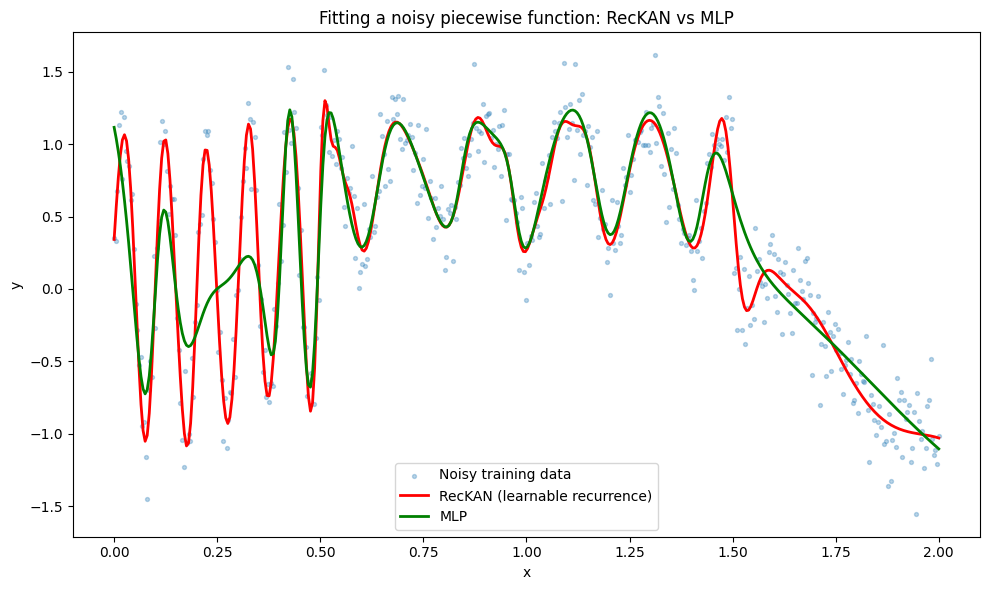

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ---------------------------------------------------------------------------
# 1) Shared learnable recurrence:
#       R_0 = 0
#       R_1 = 1
#       R_{n+1} = (a h^2 + b h + c) R_n + (d h + e) R_{n-1}
#    a, b, c, d, e are ONE set of parameters shared by the whole network
#    (init close to Chebyshev-U: a=0, b=2, c=0, d=-1, e=0)
# ---------------------------------------------------------------------------
class RecurrenceBasis(nn.Module):
    def __init__(self, degree, init=(0.0, 2.0, 0.0, -1.0, 0.0)):
        super().__init__()
        self.degree = degree
        a, b, c, d, e = init
        self.a = nn.Parameter(torch.tensor(float(a)))
        self.b = nn.Parameter(torch.tensor(float(b)))
        self.c = nn.Parameter(torch.tensor(float(c)))
        self.d = nn.Parameter(torch.tensor(float(d)))
        self.e = nn.Parameter(torch.tensor(float(e)))

    def forward(self, h):
        # h: (..., ) elementwise, already normalized to roughly [-1, 1]
        coef2 = self.a * h ** 2 + self.b * h + self.c
        coef1 = self.d * h + self.e

        R_prev2 = torch.zeros_like(h)          # R_0
        R_prev1 = torch.ones_like(h)           # R_1
        basis = [R_prev2, R_prev1]
        for _ in range(self.degree - 1):
            R_next = coef2 * R_prev1 + coef1 * R_prev2
            basis.append(R_next)
            R_prev2, R_prev1 = R_prev1, R_next
        return torch.stack(basis, dim=-1)      # (..., degree+1)


class RecKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree, basis: RecurrenceBasis):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        self.basis = basis  # shared instance -> a..e shared across layers
        self.coeffs = nn.Parameter(
            torch.randn(input_dim, output_dim, degree + 1)
            / (input_dim * (degree + 1)) ** 0.5
        )

    def forward(self, x):
        x = torch.tanh(x)                      # keep h in (-1, 1) for stability
        R = self.basis(x)                       # (batch, input_dim, degree+1)
        y = torch.einsum('bid,iod->bo', R, self.coeffs)
        return y


class RecKAN(nn.Module):
    def __init__(self, degree=8):
        super().__init__()
        self.basis = RecurrenceBasis(degree)    # <-- shared a,b,c,d,e
        self.layer1 = RecKANLayer(1, 8, degree, self.basis)
        self.layer2 = RecKANLayer(8, 1, degree, self.basis)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return x


# ---------------------------------------------------------------------------
# 2) Baseline MLP
# ---------------------------------------------------------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.layers(x - 1)


# ---------------------------------------------------------------------------
# 3) Same noisy piecewise target function as before
# ---------------------------------------------------------------------------
def target_function(x):
    y = np.zeros_like(x)
    mask1 = x < 0.5
    y[mask1] = np.sin(20 * np.pi * x[mask1]) + x[mask1] ** 2
    mask2 = (0.5 <= x) & (x < 1.5)
    y[mask2] = 0.5 * x[mask2] * np.exp(-x[mask2]) + np.abs(np.sin(5 * np.pi * x[mask2]))
    mask3 = x >= 1.5
    y[mask3] = np.log(x[mask3] - 1) / np.log(2) - np.cos(2 * np.pi * x[mask3])
    noise = np.random.normal(0, 0.2, y.shape)
    y += noise
    return y


x_train = torch.linspace(0, 2, steps=500).unsqueeze(1)
y_train = torch.tensor(target_function(x_train.numpy()), dtype=torch.float32)

reckan_model = RecKAN(degree=8)
mlp_model = SimpleMLP()

criterion = nn.MSELoss()
opt_reckan = torch.optim.Adam(reckan_model.parameters(), lr=0.01)
opt_mlp = torch.optim.Adam(mlp_model.parameters(), lr=0.03)

epochs = 50000  # reduced from 200000 for a quick run; increase for full training
reckan_losses, mlp_losses = [], []

for epoch in range(epochs):
    opt_reckan.zero_grad()
    out_reckan = reckan_model(x_train)
    loss_reckan = criterion(out_reckan, y_train)
    loss_reckan.backward()
    opt_reckan.step()

    opt_mlp.zero_grad()
    out_mlp = mlp_model(x_train)
    loss_mlp = criterion(out_mlp, y_train)
    loss_mlp.backward()
    opt_mlp.step()

    if epoch % 1000 == 0:
        reckan_losses.append(loss_reckan.item())
        mlp_losses.append(loss_mlp.item())
        print(f'Epoch {epoch}/{epochs}  RecKAN loss: {loss_reckan.item():.4f}  '
              f'MLP loss: {loss_mlp.item():.4f}')

print('\nLearned recurrence parameters (a,b,c,d,e):')
b = reckan_model.basis
print(f'a={b.a.item():.4f}  b={b.b.item():.4f}  c={b.c.item():.4f}  '
      f'd={b.d.item():.4f}  e={b.e.item():.4f}')

# ---------------------------------------------------------------------------
# 4) Evaluate + plot
# ---------------------------------------------------------------------------
x_test = torch.linspace(0, 2, steps=400).unsqueeze(1)
y_true_clean = target_function(x_test.numpy().copy())  # noisy again just for plotting scatter
with torch.no_grad():
    y_pred_reckan = reckan_model(x_test)
    y_pred_mlp = mlp_model(x_test)

plt.figure(figsize=(10, 6))
plt.scatter(x_train.numpy(), y_train.numpy(), s=8, alpha=0.3, label='Noisy training data')
plt.plot(x_test.numpy(), y_pred_reckan.numpy(), 'r-', linewidth=2, label='RecKAN (learnable recurrence)')
plt.plot(x_test.numpy(), y_pred_mlp.numpy(), 'g-', linewidth=2, label='MLP')
plt.legend()
plt.title('Fitting a noisy piecewise function: RecKAN vs MLP')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig('/home/claude/fit_comparison.png', dpi=130)

plt.figure(figsize=(8, 5))
steps_axis = np.arange(0, epochs, 1000)
plt.plot(steps_axis, reckan_losses, label='RecKAN loss')
plt.plot(steps_axis, mlp_losses, label='MLP loss')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss (log scale)')
plt.legend()
plt.title('Training loss')
plt.tight_layout()
plt.savefig('/home/claude/loss_curve.png', dpi=130)

print('\nFinal RecKAN loss:', reckan_losses[-1])
print('Final MLP loss:', mlp_losses[-1])

Epoch 1/4000, MLP Loss: 1.4788, RecKAN Loss: 0.9953 [recurrence frozen]
Epoch 101/4000, MLP Loss: 0.4734, RecKAN Loss: 0.1889 [recurrence frozen]
Epoch 201/4000, MLP Loss: 0.3658, RecKAN Loss: 0.1689
Epoch 301/4000, MLP Loss: 0.3061, RecKAN Loss: 0.1922
Epoch 401/4000, MLP Loss: 0.2668, RecKAN Loss: 0.1842
Epoch 501/4000, MLP Loss: 0.2364, RecKAN Loss: 0.1692
Epoch 601/4000, MLP Loss: 0.2249, RecKAN Loss: 0.1657
Epoch 701/4000, MLP Loss: 0.2176, RecKAN Loss: 0.1643
Epoch 801/4000, MLP Loss: 0.2144, RecKAN Loss: 0.1633
Epoch 901/4000, MLP Loss: 0.2203, RecKAN Loss: 0.1636
Epoch 1001/4000, MLP Loss: 0.2078, RecKAN Loss: 0.2145
Epoch 1101/4000, MLP Loss: 0.2083, RecKAN Loss: 0.1743
Epoch 1201/4000, MLP Loss: 0.2057, RecKAN Loss: 0.1624
Epoch 1301/4000, MLP Loss: 0.2305, RecKAN Loss: 0.1615
Epoch 1401/4000, MLP Loss: 0.2502, RecKAN Loss: 0.1605
Epoch 1501/4000, MLP Loss: 0.2165, RecKAN Loss: 0.1593
Epoch 1601/4000, MLP Loss: 0.2013, RecKAN Loss: 0.1583
Epoch 1701/4000, MLP Loss: 0.2005, Re

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fractal_2d_comparison.png'

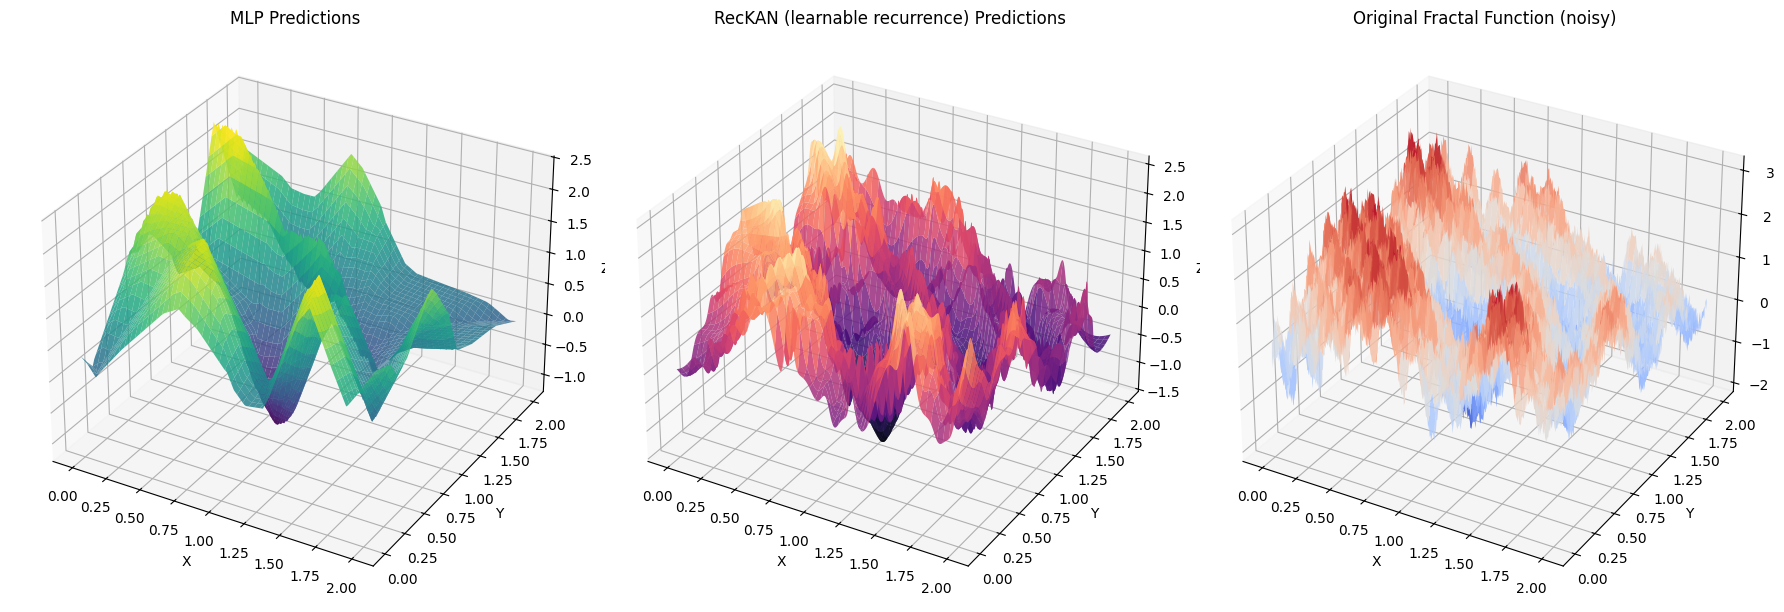

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(0)
np.random.seed(0)

# ---------------------------------------------------------------------------
# Shared learnable recurrence basis:
#   R_0 = 0, R_1 = 1
#   R_{n+1} = (a h^2 + b h + c) R_n + (d h + e) R_{n-1}
#   a, b, c, d, e -> ONE set of parameters shared across the entire network
# ---------------------------------------------------------------------------
class RecurrenceBasis(nn.Module):
    def __init__(self, degree, init=(0.0, 2.0, 0.0, -1.0, 0.0), normalize=True):
        super().__init__()
        self.degree = degree
        self.normalize = normalize
        a, b, c, d, e = init
        self.a = nn.Parameter(torch.tensor(float(a)))
        self.b = nn.Parameter(torch.tensor(float(b)))
        self.c = nn.Parameter(torch.tensor(float(c)))
        self.d = nn.Parameter(torch.tensor(float(d)))
        self.e = nn.Parameter(torch.tensor(float(e)))

        # lets the training loop freeze/unfreeze a..e during warm-up
        self.recurrence_params = [self.a, self.b, self.c, self.d, self.e]

    def forward(self, h):
        coef2 = self.a * h ** 2 + self.b * h + self.c
        coef1 = self.d * h + self.e

        R_prev2 = torch.zeros_like(h)   # R_0
        R_prev1 = torch.ones_like(h)    # R_1
        basis = [R_prev2, R_prev1]
        for _ in range(self.degree - 1):
            R_next = coef2 * R_prev1 + coef1 * R_prev2

            if self.normalize:
                # keep magnitude of successive R_n under control using a
                # single GLOBAL scalar (not per-feature!). Reducing over
                # dim=-1 (the input_dim/feature axis) would mix unrelated
                # features (e.g. x and y) together and destroy information
                # — that was the bug. A scalar keeps every feature's
                # relative scale intact while still preventing blow-up.
                scale = R_next.detach().abs().amax().clamp(min=1e-3)
                R_next = R_next / scale

            basis.append(R_next)
            R_prev2, R_prev1 = R_prev1, R_next
        return torch.stack(basis, dim=-1)   # (..., degree+1)


class RecKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, degree, basis: RecurrenceBasis):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.degree = degree
        self.basis = basis  # shared instance across all layers/network
        self.coeffs = nn.Parameter(
            torch.randn(input_dim, output_dim, degree + 1)
            / (input_dim * (degree + 1)) ** 0.5
        )

    def forward(self, x):
        x = torch.tanh(x)                 # normalize to (-1, 1)
        R = self.basis(x)                  # (batch, input_dim, degree+1)
        y = torch.einsum('bid,iod->bo', R, self.coeffs)
        return y


# 3-layer RecKAN mirroring the ChebyKAN architecture (2 -> 8 -> 16 -> 1)
class RecKAN(nn.Module):
    def __init__(self, degree=8, normalize=True):
        super().__init__()
        self.basis = RecurrenceBasis(degree, normalize=normalize)   # shared a,b,c,d,e
        self.l1 = RecKANLayer(2, 8, degree, self.basis)
        self.l2 = RecKANLayer(8, 16, degree, self.basis)
        self.l3 = RecKANLayer(16, 1, degree, self.basis)

    def forward(self, x):
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        return x

    def recurrence_parameters(self):
        return self.basis.recurrence_params

    def coeff_parameters(self):
        return [self.l1.coeffs, self.l2.coeffs, self.l3.coeffs]

    def set_recurrence_trainable(self, flag: bool):
        for p in self.recurrence_parameters():
            p.requires_grad_(flag)


# ---------------------------------------------------------------------------
# Baseline MLP (same as your reference script)
# ---------------------------------------------------------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)


# ---------------------------------------------------------------------------
# Same fractal-like noisy 2D target function
# ---------------------------------------------------------------------------
def fractal_function(x, y):
    z = np.sin(10 * np.pi * x) * np.cos(10 * np.pi * y) + np.sin(np.pi * (x ** 2 + y ** 2))
    z += np.abs(x - y) + (np.sin(5 * x * y) / (0.1 + np.abs(x + y)))
    z *= np.exp(-0.1 * (x ** 2 + y ** 2))
    noise = np.random.normal(0, 0.1, z.shape)
    z += noise
    return z


x = np.linspace(0, 2, 100)
y = np.linspace(0, 2, 100)
X, Y = np.meshgrid(x, y)
Z = fractal_function(X, Y)
x_train_2d = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)
y_train_2d = torch.tensor(Z.ravel(), dtype=torch.float32).unsqueeze(1)

mlp_model = SimpleMLP()
reckan_model = RecKAN(degree=8, normalize=True)

criterion = nn.MSELoss()
optimizer_mlp = torch.optim.Adam(mlp_model.parameters(), lr=0.01)

# --- separate LR: recurrence coefficients (a..e) move much slower than
# the per-edge linear combination weights (coeffs), since a..e sit inside
# a recursive chain and are far more sensitive ---
base_lr = 0.01
recurrence_lr_scale = 0.1
optimizer_reckan = torch.optim.Adam([
    {'params': reckan_model.coeff_parameters(), 'lr': base_lr},
    {'params': reckan_model.recurrence_parameters(), 'lr': base_lr * recurrence_lr_scale},
])

epochs = 4000
warmup_epochs = 200   # keep a..e frozen at their Chebyshev-like init at first
mlp_losses, reckan_losses = [], []

for epoch in range(epochs):
    reckan_model.set_recurrence_trainable(epoch >= warmup_epochs)

    optimizer_mlp.zero_grad()
    outputs_mlp = mlp_model(x_train_2d)
    loss_mlp = criterion(outputs_mlp, y_train_2d)
    loss_mlp.backward()
    optimizer_mlp.step()

    optimizer_reckan.zero_grad()
    outputs_reckan = reckan_model(x_train_2d)
    loss_reckan = criterion(outputs_reckan, y_train_2d)
    loss_reckan.backward()
    torch.nn.utils.clip_grad_norm_(reckan_model.parameters(), max_norm=1.0)
    optimizer_reckan.step()

    if epoch % 100 == 0:
        mlp_losses.append(loss_mlp.item())
        reckan_losses.append(loss_reckan.item())
        tag = ' [recurrence frozen]' if epoch < warmup_epochs else ''
        print(f'Epoch {epoch+1}/{epochs}, MLP Loss: {loss_mlp.item():.4f}, '
              f'RecKAN Loss: {loss_reckan.item():.4f}{tag}')

print('\nLearned recurrence parameters (a,b,c,d,e):')
b = reckan_model.basis
print(f'a={b.a.item():.4f}  b={b.b.item():.4f}  c={b.c.item():.4f}  '
      f'd={b.d.item():.4f}  e={b.e.item():.4f}')

# ---------------------------------------------------------------------------
# Test + plot
# ---------------------------------------------------------------------------
x_test = np.linspace(0, 2, 400)
y_test = np.linspace(0, 2, 400)
X_test, Y_test = np.meshgrid(x_test, y_test)
Z_test = fractal_function(X_test, Y_test)
x_test_2d = torch.tensor(np.stack([X_test.ravel(), Y_test.ravel()], axis=1), dtype=torch.float32)

with torch.no_grad():
    y_pred_mlp = mlp_model(x_test_2d).numpy()
    y_pred_reckan = reckan_model(x_test_2d).numpy()

fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X_test, Y_test, y_pred_mlp.reshape(X_test.shape), cmap='viridis', alpha=0.85)
ax1.set_title('MLP Predictions')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X_test, Y_test, y_pred_reckan.reshape(X_test.shape), cmap='magma', alpha=0.85)
ax2.set_title('RecKAN (learnable recurrence) Predictions')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X_test, Y_test, Z_test, cmap='coolwarm', alpha=0.85)
ax3.set_title('Original Fractal Function (noisy)')
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')

plt.tight_layout()
plt.savefig('/home/claude/fractal_2d_comparison.png', dpi=130)

plt.figure(figsize=(8, 5))
epochs_axis = np.arange(0, epochs, 100)
plt.plot(epochs_axis, mlp_losses, label='MLP loss')
plt.plot(epochs_axis, reckan_losses, label='RecKAN loss')
plt.yscale('log')
plt.xlabel('epoch'); plt.ylabel('MSE loss (log scale)')
plt.legend(); plt.title('2D fit training loss')
plt.tight_layout()
plt.savefig('/home/claude/fractal_2d_loss.png', dpi=130)

print('\nFinal MLP loss:', mlp_losses[-1])
print('Final RecKAN loss:', reckan_losses[-1])

In [7]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# =========================
# 1. Parameter-matched MLP baseline
#    hidden_dim=216 -> ~219,466 params, matching RecKAN's ~219,919 params
#    (RecKAN: 784->64->64->10 with degree=3, i.e. 4 coeffs per edge)
# =========================

class SimpleMLP_MNIST(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=216, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.1)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.act2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.1)

        self.fc3 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.norm1(x)
        x = self.act1(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.norm2(x)
        x = self.act2(x)
        x = self.drop2(x)

        x = self.fc3(x)
        return x


# =========================
# 2. Data loaders
# =========================

MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)


def make_mnist_loaders(batch_size=64):
    train_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD)
    ])

    train_ds = datasets.MNIST('./data_mnist',
                              train=True,
                              download=True,
                              transform=train_tf)
    test_ds = datasets.MNIST('./data_mnist',
                             train=False,
                             download=True,
                             transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=1000,
                             shuffle=False, num_workers=0)
    return train_loader, test_loader


# =========================
# 3. Training loop (identical structure/logging to the RecursivePolyKAN script)
# =========================

def train_mnist(epochs=50, batch_size=64, device='cuda', hidden_dim=216):
    print("=" * 60)
    print(f"Parameter-matched MLP (784->{hidden_dim}->{hidden_dim}->10) on MNIST")
    print(f"Device: {device} | Epochs: {epochs} | Batch: {batch_size}")
    print("=" * 60)

    train_loader, test_loader = make_mnist_loaders(batch_size=batch_size)

    model = SimpleMLP_MNIST(
        input_dim=784, hidden_dim=hidden_dim, num_classes=10
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Total trainable parameters: {n_params:,}  "
          f"(RecKAN with degree=3, hidden=64 has ~219,919)")

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_test_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        start = time.time()
        epoch_loss = 0.0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # eval روی test
        model.eval()
        correct_te, total_te = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct_te += pred.eq(target).sum().item()
                total_te += target.size(0)
        test_acc = 100.0 * correct_te / total_te
        best_test_acc = max(best_test_acc, test_acc)

        avg_loss = epoch_loss / len(train_loader)
        elapsed = time.time() - start

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Test Acc: {test_acc:.2f}% | Best Test: {best_test_acc:.2f}% "
              f"| Time: {elapsed:.1f}s")

        scheduler.step()

    return model


# =========================
# 4. Main
# =========================

if __name__ == '__main__':
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 20
    BATCH_SIZE = 64
    HIDDEN_DIM = 216   # param-matched to RecKAN (~220k params)

    model = train_mnist(epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        device=DEVICE,
                        hidden_dim=HIDDEN_DIM)

    torch.save(model.state_dict(), 'simple_mlp_mnist_paramMatched.pth')
    print("Model saved: simple_mlp_mnist_paramMatched.pth")

Parameter-matched MLP (784->216->216->10) on MNIST
Device: cuda | Epochs: 20 | Batch: 64


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.87MB/s]


Total trainable parameters: 219,466  (RecKAN with degree=3, hidden=64 has ~219,919)
Epoch  1/20 | Loss: 0.2370 | Test Acc: 95.59% | Best Test: 95.59% | Time: 14.9s
Epoch  2/20 | Loss: 0.1089 | Test Acc: 97.20% | Best Test: 97.20% | Time: 14.5s
Epoch  3/20 | Loss: 0.0841 | Test Acc: 97.85% | Best Test: 97.85% | Time: 14.5s
Epoch  4/20 | Loss: 0.0669 | Test Acc: 97.37% | Best Test: 97.85% | Time: 14.5s
Epoch  5/20 | Loss: 0.0529 | Test Acc: 97.95% | Best Test: 97.95% | Time: 14.7s
Epoch  6/20 | Loss: 0.0447 | Test Acc: 98.28% | Best Test: 98.28% | Time: 14.6s
Epoch  7/20 | Loss: 0.0375 | Test Acc: 98.08% | Best Test: 98.28% | Time: 14.5s
Epoch  8/20 | Loss: 0.0320 | Test Acc: 98.19% | Best Test: 98.28% | Time: 14.4s
Epoch  9/20 | Loss: 0.0241 | Test Acc: 98.07% | Best Test: 98.28% | Time: 14.6s
Epoch 10/20 | Loss: 0.0201 | Test Acc: 98.20% | Best Test: 98.28% | Time: 14.9s
Epoch 11/20 | Loss: 0.0176 | Test Acc: 98.32% | Best Test: 98.32% | Time: 14.6s


KeyboardInterrupt: 